In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# File paths
CLIENTS_FILE = 'CCS Clients.xlsx'
IO_FILE = 'CCS IO.xlsx'
NAARS_FILE = 'CCS NAARS.xlsx'

# Month names to process
MONTHS = ['Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Output file names
OUTPUT_CLIENT_LEVEL = 'CCS_Client_Level_Master.csv'
OUTPUT_SERVICE_DETAIL = 'CCS_Service_History_Detail.csv'
OUTPUT_ASSESSMENT_DETAIL = 'CCS_Assessment_History_Detail.csv'
OUTPUT_QUALITY_REPORT = 'CCS_Data_Quality_Report.txt'

print("="*80)
print("CCS Data Integration Pipeline")
print("="*80)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()


CCS Data Integration Pipeline
Start time: 2026-03-27 22:34:42



In [3]:
# Load CCS Clients
print("Loading CCS Clients")

try:
    clients_df = pd.read_excel(CLIENTS_FILE)
    print(f"Successfully loaded {len(clients_df)} client records")
    print(f"  Columns: {list(clients_df.columns)}")
    
    # Standardize Client UID
    clients_df['Client UID'] = clients_df['Client UID'].astype(str).str.strip()
    
    # Check for duplicates
    duplicates = clients_df['Client UID'].duplicated().sum()
    if duplicates > 0:
        print(f"⚠ WARNING: Found {duplicates} duplicate Client UIDs in master list")
        print("  Keeping first occurrence only")
        clients_df = clients_df.drop_duplicates(subset='Client UID', keep='first')
    
    # Convert dates
    date_cols = ['Birthdate', 'Arrival Date', 'Landing Date']
    for col in date_cols:
        if col in clients_df.columns:
            clients_df[col] = pd.to_datetime(clients_df[col], errors='coerce')
    
    # Calculate derived variables
    current_date = pd.Timestamp.now()
    
    if 'Birthdate' in clients_df.columns:
        clients_df['age'] = ((current_date - clients_df['Birthdate']).dt.days / 365.25).round(1)
    
    if 'Arrival Date' in clients_df.columns:
        clients_df['years_in_canada'] = ((current_date - clients_df['Arrival Date']).dt.days / 365.25).round(2)
    
    if 'Landing Date' in clients_df.columns:
        clients_df['months_since_landing'] = ((current_date - clients_df['Landing Date']).dt.days / 30.44).round(1)
    
    print(f"Date conversions complete")
    print(f"Derived variables calculated (age, years_in_canada, months_since_landing)")
    print(f"Final unique clients: {clients_df['Client UID'].nunique()}")
    
except Exception as e:
    print(f"✗ ERROR loading clients file: {e}")
    raise

print()
print(clients_df.head())

Loading CCS Clients
Successfully loaded 6796 client records
  Columns: ['Client UID', 'Birthdate', 'Gender', 'Country of Origin', 'Language', 'Postal Code', 'immigration_class', 'Arrival Date', 'Landing Date']
Date conversions complete
Derived variables calculated (age, years_in_canada, months_since_landing)
Final unique clients: 6796

                         Client UID  Birthdate  Gender Country of Origin  \
0  bec1e7cc7d46a040a3fb541cd9b4d18b 1984-01-01  Female             Sudan   
1  229e32d13f5d6aed6ea0f4f7077f26d6 1971-02-14    Male              Iraq   
2  faa368897e98e067b841481030b4ba7a 1966-12-17  Female              Iraq   
3  48ec336cd44231ebb334efbcfdeb34fa 1975-01-06    Male             Sudan   
4  e0cc94cc5f9ddd492691dd809f333818 2010-03-04    Male             Sudan   

  Language Postal Code             immigration_class Arrival Date  \
0   Arabic      M1P4X4            Permanent Resident   2021-10-24   
1   Arabic      M1R1A2  Atlantic Immigration Program          NaT  

In [4]:
# Load CCS IO (Sservices) - Monthly Sheets

print("Loading CCS IO (Services Data)")

io_dfs = []
io_load_stats = {}

for month in MONTHS:
    try:
        df = pd.read_excel(IO_FILE, sheet_name=month)
        df['data_source_month'] = month
        io_dfs.append(df)
        io_load_stats[month] = len(df)
        print(f"Loaded {month}: {len(df)} service records")
    except Exception as e:
        print(f"WARNING: Could not load sheet '{month}' from IO file: {e}")
        io_load_stats[month] = 0

if len(io_dfs) == 0:
    print("✗ ERROR: No IO data loaded. Check file path and sheet names.")
    raise ValueError("No IO data available")

# Concatenate all months
io_df = pd.concat(io_dfs, ignore_index=True)
print(f"\nSuccessfully stacked all months")
print(f"  Total service records: {len(io_df)}")
print(f"  Columns: {len(io_df.columns)}")

# Standardize Client UID
io_df['Client UID'] = io_df['Client UID'].astype(str).str.strip()

# Convert Service Date
if 'Service Date' in io_df.columns:
    io_df['Service Date'] = pd.to_datetime(io_df['Service Date'], errors='coerce')
    print(f"Service Date converted to datetime")

# Check for exact duplicates
exact_duplicates = io_df.duplicated().sum()
if exact_duplicates > 0:
    print(f"Found {exact_duplicates} exact duplicate rows - removing")
    io_df = io_df.drop_duplicates()

# Check for logical duplicates (same client, same date, same service type, same program)
if all(col in io_df.columns for col in ['Client UID', 'Service Date', 'Service Type', 'Program Name']):
    logical_dups = io_df.duplicated(subset=['Client UID', 'Service Date', 'Service Type', 'Program Name']).sum()
    if logical_dups > 0:
        print(f"Found {logical_dups} logical duplicate service records")
        print("  (Same client, date, service type, and program)")
        print("  Keeping first occurrence only")
        io_df = io_df.drop_duplicates(subset=['Client UID', 'Service Date', 'Service Type', 'Program Name'], keep='first')

print(f"Final service records after deduplication: {len(io_df)}")
print(f"Unique clients in services: {io_df['Client UID'].nunique()}")

print()

selected_cols = ['Client UID', 'Service Date', 'Service Type', 'Program Name']

print("First 5 service records (with program):")
print(io_df.head())
print()

Loading CCS IO (Services Data)
Loaded Jun: 1763 service records
Loaded Jul: 1758 service records
Loaded Aug: 2038 service records
Loaded Sep: 1993 service records
Loaded Oct: 2299 service records
Loaded Nov: 2350 service records
Loaded Dec: 1988 service records

Successfully stacked all months
  Total service records: 14189
  Columns: 18
Service Date converted to datetime
Found 320 exact duplicate rows - removing
Found 449 logical duplicate service records
  (Same client, date, service type, and program)
  Keeping first occurrence only
Final service records after deduplication: 13420
Unique clients in services: 6598

First 5 service records (with program):
                         Client UID Counsellor               Program Name  \
0  9219abc4908f00e1f4f5d0c30166073e   Gurpreet     Orientation - Brampton   
1  451717ce47bddd8d11dd359c7150179e    Zahesha     Orientation - Brampton   
2  28fa2242389a1a58e4908b7f98b278ed        Amy  Orientation - Mississauga   
3  5c7cca821e982a8cf8093877

In [5]:
# Load CCS NAARS (Assessments) - Monthly Sheets

print("Loading CCS NAARS (Assessment Data)")
print("-"*80)

naars_dfs = []
naars_load_stats = {}

for month in MONTHS:
    try:
        df = pd.read_excel(NAARS_FILE, sheet_name=month)
        df['data_source_month'] = month
        naars_dfs.append(df)
        naars_load_stats[month] = len(df)
        print(f"Loaded {month}: {len(df)} assessment records")
    except Exception as e:
        print(f"WARNING: Could not load sheet '{month}' from NAARS file: {e}")
        naars_load_stats[month] = 0

if len(naars_dfs) == 0:
    print("ERROR: No NAARS data loaded. Check file path and sheet names.")
    raise ValueError("No NAARS data available")

# Concatenate all months
naars_df = pd.concat(naars_dfs, ignore_index=True)
print(f"\nSuccessfully stacked all months")
print(f"Total assessment records: {len(naars_df)}")
print(f"Columns: {len(naars_df.columns)}")

# Standardize Client UID
naars_df['Client UID'] = naars_df['Client UID'].astype(str).str.strip()

# Convert Assessment Date
if 'Assessment Date' in naars_df.columns:
    naars_df['Assessment Date'] = pd.to_datetime(naars_df['Assessment Date'], errors='coerce')
    print(f"Assessment Date converted to datetime")

# Check for exact duplicates
exact_duplicates = naars_df.duplicated().sum()
if exact_duplicates > 0:
    print(f"Found {exact_duplicates} exact duplicate rows - removing")
    naars_df = naars_df.drop_duplicates()

print(f"Final assessment records after deduplication: {len(naars_df)}")
print(f"Unique clients in assessments: {naars_df['Client UID'].nunique()}")

print()

selected_cols = ['Client UID', 'Assessment Date', 'data_source_month']

print("First 5 assessment records:")
print(naars_df.head())
print()

Loading CCS NAARS (Assessment Data)
--------------------------------------------------------------------------------
Loaded Jun: 607 assessment records
Loaded Jul: 685 assessment records
Loaded Aug: 704 assessment records
Loaded Sep: 685 assessment records
Loaded Oct: 776 assessment records
Loaded Nov: 700 assessment records
Loaded Dec: 554 assessment records

Successfully stacked all months
Total assessment records: 4711
Columns: 99
Assessment Date converted to datetime
Final assessment records after deduplication: 4711
Unique clients in assessments: 3863

First 5 assessment records:
                         Client UID Counsellor               Program Name  \
0  9219abc4908f00e1f4f5d0c30166073e   Gurpreet     Orientation - Brampton   
1  28fa2242389a1a58e4908b7f98b278ed        Amy  Orientation - Mississauga   
2  5c7cca821e982a8cf80938776039fbad        Amy  Orientation - Mississauga   
3  537e326dc0265d070f5b0ca6dd85dfea    Daljeet     Orientation - Brampton   
4  6d0bb56dcf3e5117f04b

In [6]:
# Create Client NAARS Summary

print("Creating Client-Level NAARS Summary")

# Basic aggregations
naars_summary = naars_df.groupby('Client UID').agg({
    'Assessment Date': ['min', 'max', 'count']
}).reset_index()

naars_summary.columns = ['Client UID', 'first_assessment_date', 'last_assessment_date', 'total_assessments']

print(f"Basic assessment metrics calculated")

# Get first assessment details for each client
first_assessments = naars_df.sort_values('Assessment Date').groupby('Client UID').first().reset_index()

# Keep only relevant columns from first assessment (needs, assets, referrals)
# Identify columns related to needs, assets, and referrals
needs_cols = [col for col in first_assessments.columns if 'Needs' in col or 'Need' in col]
asset_cols = [col for col in first_assessments.columns if 'Asset' in col]
referral_cols = [col for col in first_assessments.columns if 'referral' in col]
required_cols = [col for col in first_assessments.columns if 'Required' in col]

# Keep Client UID plus these columns
first_assessment_cols = ['Client UID'] + needs_cols + asset_cols + referral_cols + required_cols
first_assessments_filtered = first_assessments[first_assessment_cols].copy()

# Rename columns to indicate they're from first assessment
rename_dict = {col: f'first_assess_{col}' for col in first_assessments_filtered.columns if col != 'Client UID'}
first_assessments_filtered = first_assessments_filtered.rename(columns=rename_dict)

# Merge with basic summary
naars_client_summary = naars_summary.merge(first_assessments_filtered, on='Client UID', how='left')

print(f"First assessment details extracted for {len(naars_client_summary)} clients")

# Calculate aggregate needs metrics
needs_binary_cols = [col for col in naars_df.columns if 'Needs' in col and naars_df[col].dtype in ['int64', 'float64', 'bool']]

if needs_binary_cols:
    # Count total needs ever identified for each client (across all assessments)
    naars_needs_counts = naars_df.groupby('Client UID')[needs_binary_cols].max().sum(axis=1).reset_index()
    naars_needs_counts.columns = ['Client UID', 'total_unique_needs_identified']
    naars_client_summary = naars_client_summary.merge(naars_needs_counts, on='Client UID', how='left')
    print(f"Total needs counts calculated")

# Calculate total referrals given
referral_binary_cols = [col for col in naars_df.columns if 'referral' in col and naars_df[col].dtype in ['int64', 'float64', 'bool']]

if referral_binary_cols:
    naars_referrals = naars_df.groupby('Client UID')[referral_binary_cols].max().sum(axis=1).reset_index()
    naars_referrals.columns = ['Client UID', 'total_referrals_given']
    naars_client_summary = naars_client_summary.merge(naars_referrals, on='Client UID', how='left')
    print(f"Total referrals counts calculated")

print(f"NAARS client-level summary complete: {len(naars_client_summary)} clients")
print(f"Columns in summary: {len(naars_client_summary.columns)}")

print()

print("First 5 assessment records:")
print(naars_df.head())
print()

Creating Client-Level NAARS Summary
Basic assessment metrics calculated
First assessment details extracted for 3863 clients
NAARS client-level summary complete: 3863 clients
Columns in summary: 77

First 5 assessment records:
                         Client UID Counsellor               Program Name  \
0  9219abc4908f00e1f4f5d0c30166073e   Gurpreet     Orientation - Brampton   
1  28fa2242389a1a58e4908b7f98b278ed        Amy  Orientation - Mississauga   
2  5c7cca821e982a8cf80938776039fbad        Amy  Orientation - Mississauga   
3  537e326dc0265d070f5b0ca6dd85dfea    Daljeet     Orientation - Brampton   
4  6d0bb56dcf3e5117f04b843959ca734e    Daljeet     Orientation - Brampton   

  Service Location Assessment Date  Assessment Duration Language Served  \
0         Brampton      2025-06-20                  1.0         English   
1      Mississauga      2025-06-02                  1.0         English   
2      Mississauga      2025-06-02                  1.0         English   
3         B

In [7]:
# Create Client-Level IO (Services) Summary

print("Creating Client-Level Services Summary")

# Basic aggregations
io_summary = io_df.groupby('Client UID').agg({
    'Service Date': ['min', 'max', 'count'],
    'Service Duration': 'sum',
    'Program Name': 'nunique',
    'Service Type': 'nunique'
}).reset_index()

io_summary.columns = ['Client UID', 'first_service_date', 'last_service_date', 
                      'total_services', 'total_service_hours', 'unique_programs', 'unique_service_types']

print(f"Basic service metrics calculated")

# Count services by service type (if Service Type column exists)
if 'Service Type' in io_df.columns:
    service_type_counts = io_df.groupby(['Client UID', 'Service Type']).size().unstack(fill_value=0)
    service_type_counts.columns = [f'services_{col.lower().replace(" ", "_")}_count' for col in service_type_counts.columns]
    service_type_counts = service_type_counts.reset_index()
    io_summary = io_summary.merge(service_type_counts, on='Client UID', how='left')
    print(f"Service counts by type calculated")

# Create binary flags for topic areas covered
topic_cols = ['National Info', 'Provincial Info', 'Community Info', 'Empl,Educ,Financ', 
              'Health-Wellbeing', 'Francophone', 'Equity', 'Indigenous']

for topic in topic_cols:
    if topic in io_df.columns:
        # Check if client received any service covering this topic
        topic_flag = io_df[io_df[topic] == 1].groupby('Client UID').size().reset_index()
        topic_flag.columns = ['Client UID', f'received_{topic.lower().replace(",", "_").replace("-", "_").replace(" ", "_")}']
        io_summary = io_summary.merge(topic_flag, on='Client UID', how='left')
        io_summary[f'received_{topic.lower().replace(",", "_").replace("-", "_").replace(" ", "_")}'] = \
            io_summary[f'received_{topic.lower().replace(",", "_").replace("-", "_").replace(" ", "_")}'].fillna(0).astype(int)

print(f"Topic coverage flags created")

print(io_df.head())

Creating Client-Level Services Summary
Basic service metrics calculated
Service counts by type calculated
Topic coverage flags created
                         Client UID Counsellor               Program Name  \
0  9219abc4908f00e1f4f5d0c30166073e   Gurpreet     Orientation - Brampton   
1  451717ce47bddd8d11dd359c7150179e    Zahesha     Orientation - Brampton   
2  28fa2242389a1a58e4908b7f98b278ed        Amy  Orientation - Mississauga   
3  5c7cca821e982a8cf80938776039fbad        Amy  Orientation - Mississauga   
4  25b716c015a18a81311488a00663d69d        Amy  Orientation - Mississauga   

         Service Location Service Date  Service Duration Language Served  \
0  Achev - Brampton South   2025-06-16               1.0         English   
1                Brampton   2025-06-17               0.5         English   
2             Mississauga   2025-06-02               1.0         English   
3             Mississauga   2025-06-02               1.0         English   
4             Mississa

In [8]:
# Create Master Dataset A

print("Merging to Create Client-Level Master Dataset")

# Start with clients as base
client_master = clients_df.copy()
print(f"Starting with {len(client_master)} clients from master list")

# Merge NAARS summary
client_master = client_master.merge(naars_client_summary, on='Client UID', how='left', indicator='_merge_naars')
naars_matched = (client_master['_merge_naars'] == 'both').sum()
print(f"Merged NAARS summary: {naars_matched} clients matched ({naars_matched/len(client_master)*100:.1f}%)")
client_master = client_master.drop(columns=['_merge_naars'])

# Merge IO summary
client_master = client_master.merge(io_summary, on='Client UID', how='left', indicator='_merge_io')
io_matched = (client_master['_merge_io'] == 'both').sum()
print(f"Merged IO summary: {io_matched} clients matched ({io_matched/len(client_master)*100:.1f}%)")
client_master = client_master.drop(columns=['_merge_io'])

# Calculate derived variables
if 'first_assessment_date' in client_master.columns and 'Landing Date' in client_master.columns:
    client_master['days_landing_to_assessment'] = \
        (client_master['first_assessment_date'] - client_master['Landing Date']).dt.days

if 'first_service_date' in client_master.columns and 'first_assessment_date' in client_master.columns:
    client_master['days_assessment_to_service'] = \
        (client_master['first_service_date'] - client_master['first_assessment_date']).dt.days

# Create engagement status
def categorize_engagement(row):
    has_assessment = pd.notna(row.get('first_assessment_date'))
    has_service = pd.notna(row.get('first_service_date'))
    
    if has_assessment and has_service:
        return 'Assessed and Served'
    elif has_assessment and not has_service:
        return 'Assessed Only'
    elif not has_assessment and has_service:
        return 'Served Only'
    else:
        return 'Not Engaged'

client_master['engagement_status'] = client_master.apply(categorize_engagement, axis=1)

print(f"Derived variables calculated")
print(f"\nEngagement Status Distribution:")
print(client_master['engagement_status'].value_counts())

print(f"\nCLIENT-LEVEL MASTER DATASET COMPLETE")
print(f"Total rows: {len(client_master)}")
print(f"Total columns: {len(client_master.columns)}")

print()

print(client_master.head())

Merging to Create Client-Level Master Dataset
Starting with 6796 clients from master list
Merged NAARS summary: 3862 clients matched (56.8%)
Merged IO summary: 6598 clients matched (97.1%)
Derived variables calculated

Engagement Status Distribution:
engagement_status
Assessed and Served    3678
Served Only            2920
Assessed Only           184
Not Engaged              14
Name: count, dtype: int64

CLIENT-LEVEL MASTER DATASET COMPLETE
Total rows: 6796
Total columns: 107

                         Client UID  Birthdate  Gender Country of Origin  \
0  bec1e7cc7d46a040a3fb541cd9b4d18b 1984-01-01  Female             Sudan   
1  229e32d13f5d6aed6ea0f4f7077f26d6 1971-02-14    Male              Iraq   
2  faa368897e98e067b841481030b4ba7a 1966-12-17  Female              Iraq   
3  48ec336cd44231ebb334efbcfdeb34fa 1975-01-06    Male             Sudan   
4  e0cc94cc5f9ddd492691dd809f333818 2010-03-04    Male             Sudan   

  Language Postal Code             immigration_class Arrival 

In [9]:
# ============================================================================
# STEP 7: CREATE SERVICE HISTORY DETAIL DATASET (DATASET B)
# ============================================================================

print("STEP 7: Creating Service History Detail Dataset")
print("-"*80)

# Merge services with client demographics
service_detail = io_df.merge(clients_df, on='Client UID', how='left', indicator='_merge_clients')

client_matched = (service_detail['_merge_clients'] == 'both').sum()
print(f"✓ Merged with client demographics: {client_matched}/{len(service_detail)} services matched ({client_matched/len(service_detail)*100:.1f}%)")

# Check for orphan services (services without matching client)
orphan_services = (service_detail['_merge_clients'] == 'left_only').sum()
if orphan_services > 0:
    print(f"⚠ WARNING: {orphan_services} service records have no matching client in master list")
    orphan_uids = service_detail[service_detail['_merge_clients'] == 'left_only']['Client UID'].unique()
    print(f"  Unique orphan Client UIDs: {len(orphan_uids)}")

service_detail = service_detail.drop(columns=['_merge_clients'])

# Add first assessment context (just key needs flags)
if 'first_assess_Live in Canada Needs' in naars_client_summary.columns:
    key_needs = ['Client UID'] + [col for col in naars_client_summary.columns if col.startswith('first_assess_') and 'Needs' in col]
    service_detail = service_detail.merge(naars_client_summary[key_needs[:15]], on='Client UID', how='left')  # Limit to first 15 need columns
    print(f"✓ Added first assessment needs context")

print(f"\n✓ SERVICE HISTORY DETAIL DATASET COMPLETE")
print(f"  Total rows: {len(service_detail)}")
print(f"  Total columns: {len(service_detail.columns)}")

print()

print("FIRST 10 SERVICE RECORDS (ALL COLUMNS):")
print("-"*80)
print(service_detail.head(10))
print()

STEP 7: Creating Service History Detail Dataset
--------------------------------------------------------------------------------
✓ Merged with client demographics: 13420/13420 services matched (100.0%)
✓ Added first assessment needs context

✓ SERVICE HISTORY DETAIL DATASET COMPLETE
  Total rows: 13420
  Total columns: 41

FIRST 10 SERVICE RECORDS (ALL COLUMNS):
--------------------------------------------------------------------------------
                         Client UID Counsellor                Program Name  \
0  9219abc4908f00e1f4f5d0c30166073e   Gurpreet      Orientation - Brampton   
1  451717ce47bddd8d11dd359c7150179e    Zahesha      Orientation - Brampton   
2  28fa2242389a1a58e4908b7f98b278ed        Amy   Orientation - Mississauga   
3  5c7cca821e982a8cf80938776039fbad        Amy   Orientation - Mississauga   
4  25b716c015a18a81311488a00663d69d        Amy   Orientation - Mississauga   
5  d86813293bdebb2aa0e266aaf8dabb6d   Pratibha           Itinerant Program   
6  25df2

In [10]:

# ============================================================================
# STEP 8: CREATE ASSESSMENT HISTORY DETAIL DATASET (DATASET C)
# ============================================================================

print("STEP 8: Creating Assessment History Detail Dataset")
print("-"*80)

# Merge assessments with client demographics
assessment_detail = naars_df.merge(clients_df, on='Client UID', how='left', indicator='_merge_clients')

client_matched = (assessment_detail['_merge_clients'] == 'both').sum()
print(f"✓ Merged with client demographics: {client_matched}/{len(assessment_detail)} assessments matched ({client_matched/len(assessment_detail)*100:.1f}%)")

# Check for orphan assessments
orphan_assessments = (assessment_detail['_merge_clients'] == 'left_only').sum()
if orphan_assessments > 0:
    print(f"⚠ WARNING: {orphan_assessments} assessment records have no matching client in master list")
    orphan_uids = assessment_detail[assessment_detail['_merge_clients'] == 'left_only']['Client UID'].unique()
    print(f"  Unique orphan Client UIDs: {len(orphan_uids)}")

assessment_detail = assessment_detail.drop(columns=['_merge_clients'])

print(f"\n✓ ASSESSMENT HISTORY DETAIL DATASET COMPLETE")
print(f"  Total rows: {len(assessment_detail)}")
print(f"  Total columns: {len(assessment_detail.columns)}")

print()

print(assessment_detail.head(10))
print()

STEP 8: Creating Assessment History Detail Dataset
--------------------------------------------------------------------------------
✓ Merged with client demographics: 4157/4711 assessments matched (88.2%)
⚠ WARNING: 554 assessment records have no matching client in master list
  Unique orphan Client UIDs: 1

✓ ASSESSMENT HISTORY DETAIL DATASET COMPLETE
  Total rows: 4711
  Total columns: 110

                         Client UID Counsellor                  Program Name  \
0  9219abc4908f00e1f4f5d0c30166073e   Gurpreet        Orientation - Brampton   
1  28fa2242389a1a58e4908b7f98b278ed        Amy     Orientation - Mississauga   
2  5c7cca821e982a8cf80938776039fbad        Amy     Orientation - Mississauga   
3  537e326dc0265d070f5b0ca6dd85dfea    Daljeet        Orientation - Brampton   
4  6d0bb56dcf3e5117f04b843959ca734e    Daljeet        Orientation - Brampton   
5  a7f919dfa2e385834ae2033c5e5ebb8a     Maripi  Settlement Integration Place   
6  70934865339cee314856bd9a617b0730     Mari

In [11]:
# ============================================================================
# STEP 9: DATA QUALITY CHECKS
# ============================================================================

print("STEP 9: Data Quality Checks")
print("-"*80)

quality_report = []

quality_report.append("="*80)
quality_report.append("CCS DATA QUALITY REPORT")
quality_report.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
quality_report.append("="*80)
quality_report.append("")

# Check 1: Join Coverage
quality_report.append("1. JOIN COVERAGE ANALYSIS")
quality_report.append("-"*80)
quality_report.append(f"Total unique clients in master list: {clients_df['Client UID'].nunique()}")
quality_report.append(f"Clients with at least one assessment: {naars_matched} ({naars_matched/len(client_master)*100:.1f}%)")
quality_report.append(f"Clients with at least one service: {io_matched} ({io_matched/len(client_master)*100:.1f}%)")

both_count = ((client_master['first_assessment_date'].notna()) & (client_master['first_service_date'].notna())).sum()
quality_report.append(f"Clients with both assessment AND service: {both_count} ({both_count/len(client_master)*100:.1f}%)")
quality_report.append("")

# Check 2: Orphan Records
quality_report.append("2. ORPHAN RECORDS (Records without matching client)")
quality_report.append("-"*80)
quality_report.append(f"Orphan service records: {orphan_services}")
quality_report.append(f"Orphan assessment records: {orphan_assessments}")
quality_report.append("")

# Check 3: Temporal Logic
quality_report.append("3. TEMPORAL LOGIC VALIDATION")
quality_report.append("-"*80)

# Services before assessment
if 'days_assessment_to_service' in client_master.columns:
    service_before_assessment = (client_master['days_assessment_to_service'] < 0).sum()
    quality_report.append(f"Clients with service BEFORE assessment: {service_before_assessment}")

# Services before landing
if 'first_service_date' in client_master.columns and 'Landing Date' in client_master.columns:
    service_before_landing = ((client_master['first_service_date'] < client_master['Landing Date']) & 
                              client_master['first_service_date'].notna() & 
                              client_master['Landing Date'].notna()).sum()
    quality_report.append(f"Clients with service BEFORE landing: {service_before_landing}")

# Assessment before landing
if 'first_assessment_date' in client_master.columns and 'Landing Date' in client_master.columns:
    assessment_before_landing = ((client_master['first_assessment_date'] < client_master['Landing Date']) & 
                                 client_master['first_assessment_date'].notna() & 
                                 client_master['Landing Date'].notna()).sum()
    quality_report.append(f"Clients with assessment BEFORE landing: {assessment_before_landing}")

quality_report.append("")

# Check 4: Missing Data Patterns
quality_report.append("4. MISSING DATA ANALYSIS - CLIENT MASTER")
quality_report.append("-"*80)

key_client_cols = ['Birthdate', 'Gender', 'Country of Origin', 'Language', 'immigration_class', 'Landing Date']
for col in key_client_cols:
    if col in client_master.columns:
        missing_pct = (client_master[col].isna().sum() / len(client_master)) * 100
        quality_report.append(f"{col:30s}: {missing_pct:5.1f}% missing")

quality_report.append("")

# Check 5: Service Date Range
quality_report.append("5. DATA DATE RANGES")
quality_report.append("-"*80)

if 'Service Date' in io_df.columns:
    min_service = io_df['Service Date'].min()
    max_service = io_df['Service Date'].max()
    quality_report.append(f"Service dates range: {min_service.strftime('%Y-%m-%d')} to {max_service.strftime('%Y-%m-%d')}")

if 'Assessment Date' in naars_df.columns:
    min_assessment = naars_df['Assessment Date'].min()
    max_assessment = naars_df['Assessment Date'].max()
    quality_report.append(f"Assessment dates range: {min_assessment.strftime('%Y-%m-%d')} to {max_assessment.strftime('%Y-%m-%d')}")

quality_report.append("")

# Check 6: Monthly Load Statistics
quality_report.append("6. MONTHLY DATA LOAD STATISTICS")
quality_report.append("-"*80)
quality_report.append("Services by month:")
for month, count in io_load_stats.items():
    quality_report.append(f"  {month}: {count:,} records")

quality_report.append("\nAssessments by month:")
for month, count in naars_load_stats.items():
    quality_report.append(f"  {month}: {count:,} records")

quality_report.append("")

# Print to console
for line in quality_report:
    print(line)

print()


STEP 9: Data Quality Checks
--------------------------------------------------------------------------------
CCS DATA QUALITY REPORT
Generated: 2026-03-27 22:35:39

1. JOIN COVERAGE ANALYSIS
--------------------------------------------------------------------------------
Total unique clients in master list: 6796
Clients with at least one assessment: 3862 (56.8%)
Clients with at least one service: 6598 (97.1%)
Clients with both assessment AND service: 3678 (54.1%)

2. ORPHAN RECORDS (Records without matching client)
--------------------------------------------------------------------------------
Orphan service records: 0
Orphan assessment records: 554

3. TEMPORAL LOGIC VALIDATION
--------------------------------------------------------------------------------
Clients with service BEFORE assessment: 351
Clients with service BEFORE landing: 4
Clients with assessment BEFORE landing: 1

4. MISSING DATA ANALYSIS - CLIENT MASTER
---------------------------------------------------------------

In [12]:
# ============================================================================
# STEP 10: SAVE OUTPUT FILES
# ============================================================================

print("STEP 10: Saving Output Files")
print("-"*80)

try:
    # Save Dataset A: Client-Level Master
    client_master.to_csv(OUTPUT_CLIENT_LEVEL, index=False)
    print(f"✓ Saved: {OUTPUT_CLIENT_LEVEL}")
    print(f"  Rows: {len(client_master):,} | Columns: {len(client_master.columns)}")
    
    # Save Dataset B: Service History Detail
    service_detail.to_csv(OUTPUT_SERVICE_DETAIL, index=False)
    print(f"✓ Saved: {OUTPUT_SERVICE_DETAIL}")
    print(f"  Rows: {len(service_detail):,} | Columns: {len(service_detail.columns)}")
    
    # Save Dataset C: Assessment History Detail
    assessment_detail.to_csv(OUTPUT_ASSESSMENT_DETAIL, index=False)
    print(f"✓ Saved: {OUTPUT_ASSESSMENT_DETAIL}")
    print(f"  Rows: {len(assessment_detail):,} | Columns: {len(assessment_detail.columns)}")
    
    # Save Quality Report
    with open(OUTPUT_QUALITY_REPORT, 'w') as f:
        f.write('\n'.join(quality_report))
    print(f"✓ Saved: {OUTPUT_QUALITY_REPORT}")
    
    print("\n" + "="*80)
    print("DATA INTEGRATION COMPLETE!")
    print("="*80)
    print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("\nNext steps:")
    print("1. Review quality report for any issues")
    print("2. Load client-level master dataset for KPI calculations")
    print("3. Use service/assessment detail datasets for deeper analysis")
    
except Exception as e:
    print(f"✗ ERROR saving files: {e}")
    raise

print()

STEP 10: Saving Output Files
--------------------------------------------------------------------------------
✓ Saved: CCS_Client_Level_Master.csv
  Rows: 6,796 | Columns: 107
✓ Saved: CCS_Service_History_Detail.csv
  Rows: 13,420 | Columns: 41
✓ Saved: CCS_Assessment_History_Detail.csv
  Rows: 4,711 | Columns: 110
✓ Saved: CCS_Data_Quality_Report.txt

DATA INTEGRATION COMPLETE!
End time: 2026-03-27 22:35:41

Next steps:
1. Review quality report for any issues
2. Load client-level master dataset for KPI calculations
3. Use service/assessment detail datasets for deeper analysis



In [13]:
# ============================================================================
# STEP 11: QUICK SUMMARY STATISTICS
# ============================================================================

print("STEP 11: Quick Summary Statistics")
print("-"*80)

print("\nCLIENT DEMOGRAPHICS:")
if 'Gender' in client_master.columns:
    print("\nGender Distribution:")
    print(client_master['Gender'].value_counts())

if 'immigration_class' in client_master.columns:
    print("\nImmigration Class Distribution:")
    print(client_master['immigration_class'].value_counts())

if 'Country of Origin' in client_master.columns:
    print("\nTop 10 Countries of Origin:")
    print(client_master['Country of Origin'].value_counts().head(10))

print("\n\nSERVICE UTILIZATION:")
if 'total_services' in client_master.columns:
    print("\nServices per Client:")
    print(client_master['total_services'].describe())

if 'total_service_hours' in client_master.columns:
    print("\nService Hours per Client:")
    print(client_master['total_service_hours'].describe())

print("\n\nASSESSMENT PATTERNS:")
if 'total_unique_needs_identified' in client_master.columns:
    print("\nNeeds Identified per Client:")
    print(client_master['total_unique_needs_identified'].describe())

if 'total_referrals_given' in client_master.columns:
    print("\nReferrals Given per Client:")
    print(client_master['total_referrals_given'].describe())

print("\n" + "="*80)
print("ALL DONE! Review the CSV files and quality report.")
print("="*80)

STEP 11: Quick Summary Statistics
--------------------------------------------------------------------------------

CLIENT DEMOGRAPHICS:

Gender Distribution:
Gender
Female    3957
Male      2833
Other        6
Name: count, dtype: int64

Immigration Class Distribution:
immigration_class
Permanent Resident                    1225
Family Sponsorship                    1142
Government-Assisted Refugee           1002
Federal Skilled Worker                 683
Privately Sponsored Refugee            520
Protected Person                       454
Refugee Claimant                       289
Canadian Citizen                       232
Convention Refugee                     208
Refugee Class                          186
Other Refugee                          120
Provincial Nominee                     113
Skilled Trades Worker                  107
Unknown                                 65
Canadian Experience                     61
Atlantic Immigration Program            57
Human-Compass Grounds   

✓ Saved: CCS_Quick_Summary.png


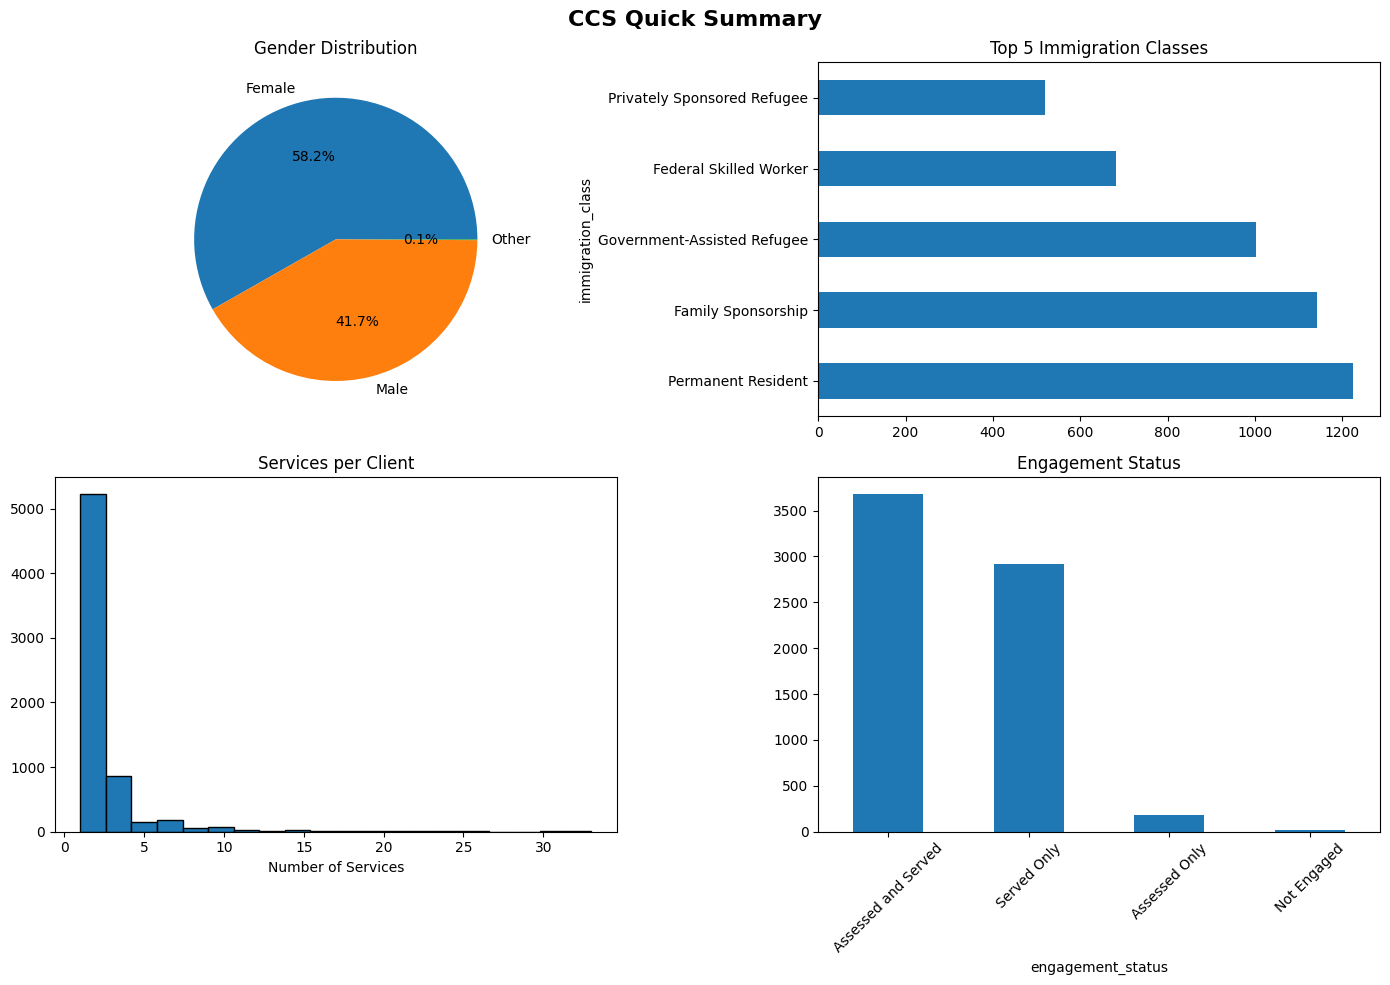

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

client_master = pd.read_csv('CCS_Client_Level_Master.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CCS Quick Summary', fontsize=16, fontweight='bold')

# Gender
if 'Gender' in client_master.columns:
    client_master['Gender'].value_counts().plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%')
    axes[0,0].set_title('Gender Distribution')
    axes[0,0].set_ylabel('')

# Immigration Class
if 'immigration_class' in client_master.columns:
    client_master['immigration_class'].value_counts().head(5).plot(kind='barh', ax=axes[0,1])
    axes[0,1].set_title('Top 5 Immigration Classes')

# Services per Client
if 'total_services' in client_master.columns:
    axes[1,0].hist(client_master['total_services'].dropna(), bins=20, edgecolor='black')
    axes[1,0].set_title('Services per Client')
    axes[1,0].set_xlabel('Number of Services')

# Engagement Status
if 'engagement_status' in client_master.columns:
    client_master['engagement_status'].value_counts().plot(kind='bar', ax=axes[1,1])
    axes[1,1].set_title('Engagement Status')
    axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('CCS_Quick_Summary.png', dpi=300, bbox_inches='tight')
print("✓ Saved: CCS_Quick_Summary.png")

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

client_master = pd.read_csv('CCS_Client_Level_Master.csv')

# ============================================================================
# ENHANCED VERSION WITH MULTIPLE VIEWS
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('CCS Clients - Countries of Origin Analysis', fontsize=18, fontweight='bold')

# ============================================================================
# TOP PANEL: Horizontal Bar Chart (Top 10)
# ============================================================================

if 'Country of Origin' in client_master.columns:
    country_counts = client_master['Country of Origin'].value_counts().head(10)
    
    # Create gradient color palette
    colors = plt.cm.viridis(range(len(country_counts)))[::-1]  # Reverse for darker = more clients
    
    bars = axes[0].barh(range(len(country_counts)), country_counts.values, 
                        color=colors, edgecolor='black', linewidth=1.5)
    
    axes[0].set_yticks(range(len(country_counts)))
    axes[0].set_yticklabels(country_counts.index, fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Number of Clients', fontsize=13, fontweight='bold')
    axes[0].set_title('Top 10 Countries of Origin', fontsize=14, fontweight='bold', pad=15)
    axes[0].invert_yaxis()
    
    # Add value and percentage labels
    total_clients = len(client_master)
    for i, (bar, value) in enumerate(zip(bars, country_counts.values)):
        percentage = (value / total_clients) * 100
        # Value label outside bar
        axes[0].text(value + 30, i, f'{value:,}', va='center', fontsize=11, fontweight='bold')
        # Percentage inside bar
        axes[0].text(value / 2, i, f'{percentage:.1f}%', va='center', ha='center', 
                    color='white', fontsize=10, fontweight='bold')
    
    axes[0].grid(axis='x', alpha=0.3, linestyle='--')
    axes[0].set_xlim(0, country_counts.values[0] * 1.15)  # Extra space for labels

# ============================================================================
# BOTTOM PANEL: Pie Chart (Top 10 + Others)
# ============================================================================

if 'Country of Origin' in client_master.columns:
    country_counts_all = client_master['Country of Origin'].value_counts()
    
    # Top 10 countries
    top10 = country_counts_all.head(10)
    
    # Group all others
    others_count = country_counts_all[10:].sum()
    
    # Combine for pie chart
    pie_data = pd.concat([top10, pd.Series({'Other Countries': others_count})])
    
    # Create pie chart
    colors_pie = list(plt.cm.Set3(range(len(top10)))) + ['#d3d3d3']  # Gray for "Others"
    
    wedges, texts, autotexts = axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
                                             startangle=90, colors=colors_pie,
                                             textprops={'fontsize': 10, 'weight': 'bold'})
    
    # Make percentage text more visible
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)
    
    axes[1].set_title('Country Distribution (Top 10 + Others)', fontsize=14, fontweight='bold', pad=15)
    
    # Add legend with counts
    legend_labels = [f'{country}: {count:,}' for country, count in pie_data.items()]
    axes[1].legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), 
                   fontsize=9, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig('CCS_Countries_Analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: CCS_Countries_Analysis.png")
plt.close()

# ============================================================================
# PRINT DETAILED STATISTICS
# ============================================================================

print("\n" + "="*80)
print("DETAILED COUNTRY OF ORIGIN STATISTICS")
print("="*80)

if 'Country of Origin' in client_master.columns:
    all_countries = client_master['Country of Origin'].value_counts()
    total = len(client_master)
    
    print(f"\nTotal Clients: {total:,}")
    print(f"Total Unique Countries: {len(all_countries)}")
    print(f"\n{'Rank':<6} {'Country':<35} {'Count':<10} {'% of Total':<12} {'Cumulative %':<15}")
    print("-"*80)
    
    cumulative = 0
    for rank, (country, count) in enumerate(all_countries.head(20).items(), 1):
        percentage = (count / total) * 100
        cumulative += percentage
        print(f"{rank:<6} {country:<35} {count:<10,} {percentage:>6.2f}%      {cumulative:>6.2f}%")
    
    if len(all_countries) > 20:
        remaining = all_countries[20:].sum()
        remaining_pct = (remaining / total) * 100
        print(f"{'...':<6} {'Other countries (combined)':<35} {remaining:<10,} {remaining_pct:>6.2f}%      {'100.00':>6}%")
    
    print("-"*80)
    print(f"{'TOTAL':<42} {total:<10,} {'100.00':>6}%")
    
    # Regional analysis
    print("\n" + "="*80)
    print("INTERESTING INSIGHTS")
    print("="*80)
    
    top_country = all_countries.index[0]
    top_count = all_countries.values[0]
    top_pct = (top_count / total) * 100
    
    print(f"\n• Most represented country: {top_country} ({top_count:,} clients, {top_pct:.1f}%)")
    
    top5_sum = all_countries.head(5).sum()
    top5_pct = (top5_sum / total) * 100
    print(f"• Top 5 countries represent: {top5_sum:,} clients ({top5_pct:.1f}%)")
    
    top10_sum = all_countries.head(10).sum()
    top10_pct = (top10_sum / total) * 100
    print(f"• Top 10 countries represent: {top10_sum:,} clients ({top10_pct:.1f}%)")
    
    # Diversity metric (countries representing 80% of clients)
    cumulative_pct = 0
    countries_for_80pct = 0
    for count in all_countries.values:
        cumulative_pct += (count / total) * 100
        countries_for_80pct += 1
        if cumulative_pct >= 80:
            break
    
    print(f"• {countries_for_80pct} countries account for 80% of all clients")
    print(f"• Remaining {len(all_countries) - countries_for_80pct} countries account for 20% of clients")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

✓ Saved: CCS_Countries_Analysis.png

DETAILED COUNTRY OF ORIGIN STATISTICS

Total Clients: 6,796
Total Unique Countries: 133

Rank   Country                             Count      % of Total   Cumulative %   
--------------------------------------------------------------------------------
1      Afghanistan                         1,374       20.22%       20.22%
2      China                               844         12.42%       32.64%
3      India                               805         11.85%       44.48%
4      Syria                               331          4.87%       49.35%
5      Pakistan                            268          3.94%       53.30%
6      Bangladesh                          246          3.62%       56.92%
7      Eritrea                             236          3.47%       60.39%
8      Nigeria                             174          2.56%       62.95%
9      Colombia                            173          2.55%       65.49%
10     Sri Lanka                   

In [16]:

# ============================================================================
# STEP 9: DATA QUALITY CHECKS
# ============================================================================

print("STEP 9: Data Quality Checks")
print("-"*80)

quality_report = []

quality_report.append("="*80)
quality_report.append("CCS DATA QUALITY REPORT")
quality_report.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
quality_report.append("="*80)
quality_report.append("")

# Check 1: Join Coverage
quality_report.append("1. JOIN COVERAGE ANALYSIS")
quality_report.append("-"*80)
quality_report.append(f"Total unique clients in master list: {clients_df['Client UID'].nunique()}")
quality_report.append(f"Clients with at least one assessment: {naars_matched} ({naars_matched/len(client_master)*100:.1f}%)")
quality_report.append(f"Clients with at least one service: {io_matched} ({io_matched/len(client_master)*100:.1f}%)")

both_count = ((client_master['first_assessment_date'].notna()) & (client_master['first_service_date'].notna())).sum()
quality_report.append(f"Clients with both assessment AND service: {both_count} ({both_count/len(client_master)*100:.1f}%)")
quality_report.append("")

# Check 2: Orphan Records
quality_report.append("2. ORPHAN RECORDS (Records without matching client)")
quality_report.append("-"*80)
quality_report.append(f"Orphan service records: {orphan_services}")
quality_report.append(f"Orphan assessment records: {orphan_assessments}")
quality_report.append("")

# Check 3: Temporal Logic
quality_report.append("3. TEMPORAL LOGIC VALIDATION")
quality_report.append("-"*80)

# Services before assessment
if 'days_assessment_to_service' in client_master.columns:
    service_before_assessment = (client_master['days_assessment_to_service'] < 0).sum()
    quality_report.append(f"Clients with service BEFORE assessment: {service_before_assessment}")

# Services before landing
if 'first_service_date' in client_master.columns and 'Landing Date' in client_master.columns:
    service_before_landing = ((client_master['first_service_date'] < client_master['Landing Date']) & 
                              client_master['first_service_date'].notna() & 
                              client_master['Landing Date'].notna()).sum()
    quality_report.append(f"Clients with service BEFORE landing: {service_before_landing}")

# Assessment before landing
if 'first_assessment_date' in client_master.columns and 'Landing Date' in client_master.columns:
    assessment_before_landing = ((client_master['first_assessment_date'] < client_master['Landing Date']) & 
                                 client_master['first_assessment_date'].notna() & 
                                 client_master['Landing Date'].notna()).sum()
    quality_report.append(f"Clients with assessment BEFORE landing: {assessment_before_landing}")

quality_report.append("")

# Check 4: Missing Data Patterns
quality_report.append("4. MISSING DATA ANALYSIS - CLIENT MASTER")
quality_report.append("-"*80)

key_client_cols = ['Birthdate', 'Gender', 'Country of Origin', 'Language', 'immigration_class', 'Landing Date']
for col in key_client_cols:
    if col in client_master.columns:
        missing_pct = (client_master[col].isna().sum() / len(client_master)) * 100
        quality_report.append(f"{col:30s}: {missing_pct:5.1f}% missing")

quality_report.append("")

# Check 5: Service Date Range
quality_report.append("5. DATA DATE RANGES")
quality_report.append("-"*80)

if 'Service Date' in io_df.columns:
    min_service = io_df['Service Date'].min()
    max_service = io_df['Service Date'].max()
    quality_report.append(f"Service dates range: {min_service.strftime('%Y-%m-%d')} to {max_service.strftime('%Y-%m-%d')}")

if 'Assessment Date' in naars_df.columns:
    min_assessment = naars_df['Assessment Date'].min()
    max_assessment = naars_df['Assessment Date'].max()
    quality_report.append(f"Assessment dates range: {min_assessment.strftime('%Y-%m-%d')} to {max_assessment.strftime('%Y-%m-%d')}")

quality_report.append("")

# Check 6: Monthly Load Statistics
quality_report.append("6. MONTHLY DATA LOAD STATISTICS")
quality_report.append("-"*80)
quality_report.append("Services by month:")
for month, count in io_load_stats.items():
    quality_report.append(f"  {month}: {count:,} records")

quality_report.append("\nAssessments by month:")
for month, count in naars_load_stats.items():
    quality_report.append(f"  {month}: {count:,} records")

quality_report.append("")

# Print to console
for line in quality_report:
    print(line)

print()

# ============================================================================
# STEP 10: SAVE OUTPUT FILES
# ============================================================================

print("STEP 10: Saving Output Files")
print("-"*80)

try:
    # Save Dataset A: Client-Level Master
    client_master.to_csv(OUTPUT_CLIENT_LEVEL, index=False)
    print(f"✓ Saved: {OUTPUT_CLIENT_LEVEL}")
    print(f"  Rows: {len(client_master):,} | Columns: {len(client_master.columns)}")
    
    # Save Dataset B: Service History Detail
    service_detail.to_csv(OUTPUT_SERVICE_DETAIL, index=False)
    print(f"✓ Saved: {OUTPUT_SERVICE_DETAIL}")
    print(f"  Rows: {len(service_detail):,} | Columns: {len(service_detail.columns)}")
    
    # Save Dataset C: Assessment History Detail
    assessment_detail.to_csv(OUTPUT_ASSESSMENT_DETAIL, index=False)
    print(f"✓ Saved: {OUTPUT_ASSESSMENT_DETAIL}")
    print(f"  Rows: {len(assessment_detail):,} | Columns: {len(assessment_detail.columns)}")
    
    # Save Quality Report
    with open(OUTPUT_QUALITY_REPORT, 'w') as f:
        f.write('\n'.join(quality_report))
    print(f"✓ Saved: {OUTPUT_QUALITY_REPORT}")
    
    print("\n" + "="*80)
    print("DATA INTEGRATION COMPLETE!")
    print("="*80)
    print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("\nNext steps:")
    print("1. Review quality report for any issues")
    print("2. Load client-level master dataset for KPI calculations")
    print("3. Use service/assessment detail datasets for deeper analysis")
    
except Exception as e:
    print(f"✗ ERROR saving files: {e}")
    raise

print()

# ============================================================================
# STEP 11: QUICK SUMMARY STATISTICS
# ============================================================================

print("STEP 11: Quick Summary Statistics")
print("-"*80)

print("\nCLIENT DEMOGRAPHICS:")
if 'Gender' in client_master.columns:
    print("\nGender Distribution:")
    print(client_master['Gender'].value_counts())

if 'immigration_class' in client_master.columns:
    print("\nImmigration Class Distribution:")
    print(client_master['immigration_class'].value_counts())

if 'Country of Origin' in client_master.columns:
    print("\nTop 10 Countries of Origin:")
    print(client_master['Country of Origin'].value_counts().head(10))

print("\n\nSERVICE UTILIZATION:")
if 'total_services' in client_master.columns:
    print("\nServices per Client:")
    print(client_master['total_services'].describe())

if 'total_service_hours' in client_master.columns:
    print("\nService Hours per Client:")
    print(client_master['total_service_hours'].describe())

print("\n\nASSESSMENT PATTERNS:")
if 'total_unique_needs_identified' in client_master.columns:
    print("\nNeeds Identified per Client:")
    print(client_master['total_unique_needs_identified'].describe())

if 'total_referrals_given' in client_master.columns:
    print("\nReferrals Given per Client:")
    print(client_master['total_referrals_given'].describe())

print("\n" + "="*80)
print("ALL DONE! Review the CSV files and quality report.")
print("="*80)

STEP 9: Data Quality Checks
--------------------------------------------------------------------------------
CCS DATA QUALITY REPORT
Generated: 2026-03-27 22:35:57

1. JOIN COVERAGE ANALYSIS
--------------------------------------------------------------------------------
Total unique clients in master list: 6796
Clients with at least one assessment: 3862 (56.8%)
Clients with at least one service: 6598 (97.1%)
Clients with both assessment AND service: 3678 (54.1%)

2. ORPHAN RECORDS (Records without matching client)
--------------------------------------------------------------------------------
Orphan service records: 0
Orphan assessment records: 554

3. TEMPORAL LOGIC VALIDATION
--------------------------------------------------------------------------------
Clients with service BEFORE assessment: 351
Clients with service BEFORE landing: 4
Clients with assessment BEFORE landing: 1

4. MISSING DATA ANALYSIS - CLIENT MASTER
---------------------------------------------------------------

In [17]:
import os

csv_path = os.path.join(os.getcwd(), 'CCS_Client_Level_Master.csv')

dashboard_code = f'''import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import io

st.set_page_config(page_title="CCS Analytics Dashboard", layout="wide", initial_sidebar_state="expanded")

st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Roboto:wght@300;400;500;700&display=swap');
    
    * {{font-family: 'Roboto', sans-serif;}}
    .main {{background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); padding: 2rem;}}
    .stApp {{background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%);}}
    
    h1 {{
        background: rgba(255, 255, 255, 0.08);
        backdrop-filter: blur(10px);
        color: #ffffff !important;
        padding: 2rem;
        border-radius: 12px;
        text-align: center;
        margin-bottom: 2rem;
        box-shadow: 0 8px 32px rgba(0,0,0,0.3);
        font-weight: 500;
        border: 1px solid rgba(255, 255, 255, 0.18);
    }}
    
    h2, h3, h4 {{color: #ffffff !important; font-weight: 500;}}
    p, label, .stMarkdown {{color: #e8eaf6 !important;}}
    
    div[data-testid="metric-container"] {{
        background: rgba(255, 255, 255, 0.1);
        backdrop-filter: blur(10px);
        border-radius: 10px;
        padding: 1.5rem;
        box-shadow: 0 4px 15px rgba(0,0,0,0.2);
        border: 1px solid rgba(255, 255, 255, 0.18);
        transition: all 0.3s ease;
    }}
    
    div[data-testid="metric-container"]:hover {{
        background: rgba(255, 255, 255, 0.15);
        transform: translateY(-3px);
        box-shadow: 0 6px 20px rgba(0,0,0,0.3);
    }}
    
    div[data-testid="stMetricValue"] {{
        font-size: 2.2rem;
        font-weight: 700;
        color: #ffffff !important;
    }}
    
    div[data-testid="stMetricLabel"] {{
        font-size: 0.85rem;
        color: #b0bec5 !important;
        font-weight: 500;
    }}
    
    div[data-testid="stMetricDelta"] {{
        font-size: 0.8rem;
        color: #90caf9 !important;
    }}
    
    div[data-testid="stSidebar"] {{
        background: rgba(255, 255, 255, 0.08);
        backdrop-filter: blur(10px);
        border-right: 1px solid rgba(255, 255, 255, 0.15);
    }}
    
    .stTabs [data-baseweb="tab-list"] {{
        gap: 8px;
        background: rgba(255, 255, 255, 0.05);
        padding: 8px;
        border-radius: 10px;
    }}
    
    .stTabs [data-baseweb="tab"] {{
        background: rgba(255, 255, 255, 0.1);
        border-radius: 8px;
        padding: 12px 24px;
        color: #ffffff;
        font-weight: 500;
    }}
    
    .stTabs [aria-selected="true"] {{
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
    }}
    
    .stDataFrame {{background: rgba(255, 255, 255, 0.08); border-radius: 10px;}}
    table {{color: #ffffff !important;}}
    thead tr th {{background: rgba(102, 126, 234, 0.3) !important; color: #ffffff !important; font-weight: 600;}}
    tbody tr td {{color: #e0e0e0 !important; border-bottom: 1px solid rgba(255, 255, 255, 0.1) !important;}}
    
    .upload-section {{
        background: rgba(255, 255, 255, 0.1);
        padding: 1.5rem;
        border-radius: 10px;
        border: 2px dashed rgba(255, 255, 255, 0.3);
        margin-bottom: 1rem;
    }}
</style>
""", unsafe_allow_html=True)

def merge_uploaded_data(clients_file, io_file, naars_file):
    try:
        clients_df = pd.read_excel(clients_file)
        clients_df['Client UID'] = clients_df['Client UID'].astype(str).str.strip()
        
        date_cols = ['Birthdate', 'Arrival Date', 'Landing Date']
        for col in date_cols:
            if col in clients_df.columns:
                clients_df[col] = pd.to_datetime(clients_df[col], errors='coerce')
        
        current_date = pd.Timestamp.now()
        if 'Birthdate' in clients_df.columns:
            clients_df['age'] = ((current_date - clients_df['Birthdate']).dt.days / 365.25).round(1)
        if 'Arrival Date' in clients_df.columns:
            clients_df['years_in_canada'] = ((current_date - clients_df['Arrival Date']).dt.days / 365.25).round(2)
        if 'Landing Date' in clients_df.columns:
            clients_df['months_since_landing'] = ((current_date - clients_df['Landing Date']).dt.days / 30.44).round(1)
        
        io_sheets = pd.read_excel(io_file, sheet_name=None)
        io_dfs = []
        for sheet_name, df in io_sheets.items():
            df['data_source_month'] = sheet_name
            io_dfs.append(df)
        io_df = pd.concat(io_dfs, ignore_index=True)
        io_df['Client UID'] = io_df['Client UID'].astype(str).str.strip()
        if 'Service Date' in io_df.columns:
            io_df['Service Date'] = pd.to_datetime(io_df['Service Date'], errors='coerce')
        io_df = io_df.drop_duplicates()
        
        naars_sheets = pd.read_excel(naars_file, sheet_name=None)
        naars_dfs = []
        for sheet_name, df in naars_sheets.items():
            df['data_source_month'] = sheet_name
            naars_dfs.append(df)
        naars_df = pd.concat(naars_dfs, ignore_index=True)
        naars_df['Client UID'] = naars_df['Client UID'].astype(str).str.strip()
        if 'Assessment Date' in naars_df.columns:
            naars_df['Assessment Date'] = pd.to_datetime(naars_df['Assessment Date'], errors='coerce')
        naars_df = naars_df.drop_duplicates()
        
        naars_summary = naars_df.groupby('Client UID').agg({{
            'Assessment Date': ['min', 'max', 'count']
        }}).reset_index()
        naars_summary.columns = ['Client UID', 'first_assessment_date', 'last_assessment_date', 'total_assessments']
        
        first_assessments = naars_df.sort_values('Assessment Date').groupby('Client UID').first().reset_index()
        needs_cols = [col for col in first_assessments.columns if 'Needs' in col or 'Need' in col]
        asset_cols = [col for col in first_assessments.columns if 'Asset' in col]
        referral_cols = [col for col in first_assessments.columns if 'referral' in col]
        required_cols = [col for col in first_assessments.columns if 'Required' in col]
        
        first_assessment_cols = ['Client UID'] + needs_cols + asset_cols + referral_cols + required_cols
        first_assessments_filtered = first_assessments[first_assessment_cols].copy()
        rename_dict = {{col: f'first_assess_{{col}}' for col in first_assessments_filtered.columns if col != 'Client UID'}}
        first_assessments_filtered = first_assessments_filtered.rename(columns=rename_dict)
        
        naars_client_summary = naars_summary.merge(first_assessments_filtered, on='Client UID', how='left')
        
        io_summary = io_df.groupby('Client UID').agg({{
            'Service Date': ['min', 'max', 'count'],
            'Service Duration': 'sum',
            'Program Name': 'nunique',
            'Service Type': 'nunique'
        }}).reset_index()
        io_summary.columns = ['Client UID', 'first_service_date', 'last_service_date', 
                              'total_services', 'total_service_hours', 'unique_programs', 'unique_service_types']
        
        if 'Service Type' in io_df.columns:
            service_type_counts = io_df.groupby(['Client UID', 'Service Type']).size().unstack(fill_value=0)
            service_type_counts.columns = [f'services_{{col.lower().replace(" ", "_")}}_count' for col in service_type_counts.columns]
            service_type_counts = service_type_counts.reset_index()
            io_summary = io_summary.merge(service_type_counts, on='Client UID', how='left')
        
        topic_cols = ['National Info', 'Provincial Info', 'Community Info', 'Empl,Educ,Financ', 
                      'Health-Wellbeing', 'Francophone', 'Equity', 'Indigenous']
        for topic in topic_cols:
            if topic in io_df.columns:
                topic_flag = io_df[io_df[topic] == 1].groupby('Client UID').size().reset_index()
                topic_flag.columns = ['Client UID', f'received_{{topic.lower().replace(",", "_").replace("-", "_").replace(" ", "_")}}']
                io_summary = io_summary.merge(topic_flag, on='Client UID', how='left')
                io_summary[f'received_{{topic.lower().replace(",", "_").replace("-", "_").replace(" ", "_")}}'] = \\
                    io_summary[f'received_{{topic.lower().replace(",", "_").replace("-", "_").replace(" ", "_")}}'].fillna(0).astype(int)
        
        client_master = clients_df.copy()
        client_master = client_master.merge(naars_client_summary, on='Client UID', how='left')
        client_master = client_master.merge(io_summary, on='Client UID', how='left')
        
        if 'first_assessment_date' in client_master.columns and 'Landing Date' in client_master.columns:
            client_master['days_landing_to_assessment'] = \\
                (client_master['first_assessment_date'] - client_master['Landing Date']).dt.days
        
        if 'first_service_date' in client_master.columns and 'first_assessment_date' in client_master.columns:
            client_master['days_assessment_to_service'] = \\
                (client_master['first_service_date'] - client_master['first_assessment_date']).dt.days
        
        def categorize_engagement(row):
            has_assessment = pd.notna(row.get('first_assessment_date'))
            has_service = pd.notna(row.get('first_service_date'))
            if has_assessment and has_service:
                return 'Assessed and Served'
            elif has_assessment and not has_service:
                return 'Assessed Only'
            elif not has_assessment and has_service:
                return 'Served Only'
            else:
                return 'Not Engaged'
        
        client_master['engagement_status'] = client_master.apply(categorize_engagement, axis=1)
        
        return client_master, "Data processed successfully!"
    
    except Exception as e:
        return None, f"Error processing data: {{str(e)}}"

if 'uploaded_data' not in st.session_state:
    st.session_state.uploaded_data = None
if 'use_uploaded' not in st.session_state:
    st.session_state.use_uploaded = False

st.title("CCS Outcome Measurement Dashboard")

st.sidebar.markdown("### Data Source")
st.sidebar.markdown("")

data_source = st.sidebar.radio(
    "Select data source:",
    ["Default Data (Jun-Dec 2024)", "Upload New Data"],
    key='data_source'
)

if data_source == "Upload New Data":
    st.sidebar.markdown('<div class="upload-section">', unsafe_allow_html=True)
    st.sidebar.markdown("#### Upload Files")
    
    clients_file = st.sidebar.file_uploader("Clients Excel File", type=['xlsx'], key='clients')
    io_file = st.sidebar.file_uploader("Services (IO) Excel File", type=['xlsx'], key='io')
    naars_file = st.sidebar.file_uploader("Assessments (NAARS) Excel File", type=['xlsx'], key='naars')
    
    if clients_file and io_file and naars_file:
        if st.sidebar.button("Process Uploaded Data", type="primary"):
            with st.spinner("Processing data..."):
                processed_data, message = merge_uploaded_data(clients_file, io_file, naars_file)
                
                if processed_data is not None:
                    st.session_state.uploaded_data = processed_data
                    st.session_state.use_uploaded = True
                    st.sidebar.success(message)
                    st.rerun()
                else:
                    st.sidebar.error(message)
    else:
        st.sidebar.info("Upload all 3 files to process")
    
    st.sidebar.markdown('</div>', unsafe_allow_html=True)

@st.cache_data
def load_default_data():
    df = pd.read_csv(r"{csv_path}")
    date_cols = ['Birthdate', 'Landing Date', 'Arrival Date', 'first_assessment_date', 
                 'first_service_date', 'last_assessment_date', 'last_service_date']
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

if st.session_state.use_uploaded and st.session_state.uploaded_data is not None:
    client_master = st.session_state.uploaded_data
    data_label = "Uploaded Data"
else:
    client_master = load_default_data()
    data_label = "Jun-Dec 2024"

st.markdown(f"<p style='text-align: center; color: #b0bec5; font-size: 1rem; margin-top: -1.5rem;'><strong>Data Source:</strong> {{data_label}} | <strong>Total Clients:</strong> {{len(client_master):,}} | <strong>Last Updated:</strong> {{datetime.now().strftime('%Y-%m-%d %H:%M')}}</p>", unsafe_allow_html=True)

st.sidebar.markdown("---")
st.sidebar.markdown("### Dashboard Filters")
st.sidebar.markdown("")

if 'immigration_class' in client_master.columns:
    immigration_classes = ['All'] + sorted(client_master['immigration_class'].dropna().unique().tolist())
    selected_class = st.sidebar.selectbox("Immigration Class", immigration_classes)
else:
    selected_class = 'All'

if 'Country of Origin' in client_master.columns:
    countries = ['All'] + sorted(client_master['Country of Origin'].dropna().unique().tolist())
    selected_country = st.sidebar.selectbox("Country of Origin", countries)
else:
    selected_country = 'All'

filtered_df = client_master.copy()
if selected_class != 'All':
    filtered_df = filtered_df[filtered_df['immigration_class'] == selected_class]
if selected_country != 'All':
    filtered_df = filtered_df[filtered_df['Country of Origin'] == selected_country]

st.sidebar.markdown("---")
filter_pct = len(filtered_df)/len(client_master)*100
st.sidebar.metric("Filtered Clients", f"{{len(filtered_df):,}}", f"{{filter_pct:.1f}}%")

total_clients = len(filtered_df)
assessed_clients = filtered_df['first_assessment_date'].notna().sum()
served_clients = filtered_df['first_service_date'].notna().sum()
assessment_rate = (assessed_clients / total_clients * 100) if total_clients > 0 else 0
service_rate = (served_clients / total_clients * 100) if total_clients > 0 else 0

days_to_assessment = filtered_df['days_landing_to_assessment'].dropna()
avg_days_to_assessment = days_to_assessment.mean() if len(days_to_assessment) > 0 else None

days_to_service = filtered_df['days_assessment_to_service'].abs().dropna()
avg_days_to_service = days_to_service.mean() if len(days_to_service) > 0 else None

if 'first_service_date' in filtered_df.columns and 'last_service_date' in filtered_df.columns:
    engagement_duration = (filtered_df['last_service_date'] - filtered_df['first_service_date']).dt.days.abs()
    multi_month = (engagement_duration >= 30).sum()
    retention_rate = (multi_month / served_clients * 100) if served_clients > 0 else 0
else:
    retention_rate = 0
    multi_month = 0

tab1, tab2, tab3, tab4 = st.tabs([
    "Overview",
    "Client Access & Engagement",
    "Demographics & Characteristics", 
    "Assessment Quality"
])

with tab1:
    st.markdown("## Executive Summary")
    st.markdown("")
    
    col1, col2, col3, col4 = st.columns(4)
    
    with col1:
        st.metric("Total Clients", f"{{total_clients:,}}")
    with col2:
        st.metric("Assessment Rate", f"{{assessment_rate:.1f}}%", f"{{assessed_clients:,}} clients")
    with col3:
        st.metric("Service Rate", f"{{service_rate:.1f}}%", f"{{served_clients:,}} clients")
    with col4:
        avg_services = filtered_df['total_services'].mean() if 'total_services' in filtered_df.columns else 0
        st.metric("Avg Services/Client", f"{{avg_services:.1f}}")
    
    st.markdown('<div style="margin: 2rem 0;"></div>', unsafe_allow_html=True)
    
    row1_col1, row1_col2 = st.columns([1, 1])
    
    with row1_col1:
        st.markdown("### Engagement Status Overview")
        
        if 'engagement_status' in filtered_df.columns:
            engagement_counts = filtered_df['engagement_status'].value_counts().reset_index()
            engagement_counts.columns = ['Status', 'Count']
            
            fig = px.bar(
                engagement_counts,
                x='Status',
                y='Count',
                text='Count',
                color='Status',
                color_discrete_map={{
                    'Assessed and Served': '#2ecc71',
                    'Assessed Only': '#f39c12',
                    'Served Only': '#3498db',
                    'Not Engaged': '#95a5a6'
                }}
            )
            
            fig.update_traces(
                texttemplate='%{{text:,}}',
                textposition='outside',
                textfont=dict(size=11, color='#ffffff'),
                marker_line_color='rgba(30, 60, 114, 0.8)',
                marker_line_width=2
            )
            
            fig.update_layout(
                height=400,
                margin=dict(t=20, b=90, l=60, r=20),
                xaxis_title='Engagement Category',
                yaxis_title='Number of Clients',
                showlegend=False,
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(255,255,255,0.02)',
                font=dict(color='#ffffff'),
                xaxis=dict(tickangle=-15, showgrid=False),
                yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)')
            )
            
            st.plotly_chart(fig, use_container_width=True)
    
    with row1_col2:
        st.markdown("### Top 10 Countries of Origin")
        
        if 'Country of Origin' in filtered_df.columns:
            country_counts = filtered_df['Country of Origin'].value_counts().head(10).reset_index()
            country_counts.columns = ['Country', 'Count']
            
            fig = px.bar(
                country_counts,
                y='Country',
                x='Count',
                orientation='h',
                text='Count',
                color='Count',
                color_continuous_scale='Viridis'
            )
            
            fig.update_traces(
                texttemplate='%{{text:,}}',
                textposition='outside',
                textfont=dict(size=11, color='#ffffff'),
                marker_line_color='rgba(30, 60, 114, 0.8)',
                marker_line_width=1.5
            )
            
            fig.update_layout(
                height=400,
                margin=dict(t=20, b=40, l=120, r=40),
                xaxis_title='Number of Clients',
                yaxis_title='Country',
                showlegend=False,
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(255,255,255,0.02)',
                font=dict(color='#ffffff'),
                xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
                yaxis=dict(showgrid=False)
            )
            
            st.plotly_chart(fig, use_container_width=True)

with tab2:
    st.markdown("## Client Access & Engagement Metrics")
    st.markdown("")
    
    col1, col2, col3, col4, col5 = st.columns(5)
    
    with col1:
        st.metric("Assessment Coverage", f"{{assessment_rate:.1f}}%", f"{{assessed_clients:,}} / {{total_clients:,}}")
        if assessment_rate >= 90:
            st.markdown('<p style="color: #2ecc71; font-weight: 600; font-size: 0.8rem;">Target: ≥90%</p>', unsafe_allow_html=True)
        else:
            st.markdown('<p style="color: #f39c12; font-weight: 600; font-size: 0.8rem;">Target: ≥90%</p>', unsafe_allow_html=True)
    
    with col2:
        if avg_days_to_assessment:
            within = (days_to_assessment <= 30).sum()/len(days_to_assessment)*100
            st.metric("Days to Assessment", f"{{avg_days_to_assessment:.0f}}", f"{{within:.0f}}% ≤30d")
            if avg_days_to_assessment <= 30:
                st.markdown('<p style="color: #2ecc71; font-weight: 600; font-size: 0.8rem;">Target: ≤30d</p>', unsafe_allow_html=True)
            else:
                st.markdown('<p style="color: #f39c12; font-weight: 600; font-size: 0.8rem;">Target: ≤30d</p>', unsafe_allow_html=True)
        else:
            st.metric("Days to Assessment", "N/A")
    
    with col3:
        if avg_days_to_service:
            within = (days_to_service <= 14).sum()/len(days_to_service)*100
            st.metric("Days to Service", f"{{avg_days_to_service:.0f}}", f"{{within:.0f}}% ≤14d")
            if avg_days_to_service <= 14:
                st.markdown('<p style="color: #2ecc71; font-weight: 600; font-size: 0.8rem;">Target: ≤14d</p>', unsafe_allow_html=True)
            else:
                st.markdown('<p style="color: #f39c12; font-weight: 600; font-size: 0.8rem;">Target: ≤14d</p>', unsafe_allow_html=True)
        else:
            st.metric("Days to Service", "N/A")
    
    with col4:
        st.metric("Service Participation", f"{{service_rate:.1f}}%", f"{{served_clients:,}} / {{total_clients:,}}")
        if service_rate >= 95:
            st.markdown('<p style="color: #2ecc71; font-weight: 600; font-size: 0.8rem;">Target: ≥95%</p>', unsafe_allow_html=True)
        else:
            st.markdown('<p style="color: #3498db; font-weight: 600; font-size: 0.8rem;">Monitoring</p>', unsafe_allow_html=True)
    
    with col5:
        st.metric("Client Retention", f"{{retention_rate:.1f}}%", f"{{int(multi_month):,}} clients")
        st.markdown('<p style="color: #3498db; font-weight: 600; font-size: 0.8rem;">Monitoring</p>', unsafe_allow_html=True)
    
    st.markdown('<div style="margin: 2rem 0;"></div>', unsafe_allow_html=True)
    
    row1_col1, row1_col2 = st.columns([1, 1])
    
    with row1_col1:
        st.markdown("### Assessment Coverage")
        
        assessment_data = pd.DataFrame({{
            'Status': ['Assessed', 'Not Assessed'],
            'Count': [assessed_clients, total_clients - assessed_clients]
        }})
        
        fig = px.pie(
            assessment_data,
            values='Count',
            names='Status',
            hole=0.5,
            color='Status',
            color_discrete_map={{'Assessed': '#2ecc71', 'Not Assessed': '#e74c3c'}}
        )
        
        fig.update_traces(
            textposition='outside',
            textinfo='label+percent',
            textfont=dict(size=13, color='#ffffff'),
            pull=[0.05, 0.05],
            marker=dict(line=dict(color='rgba(30, 60, 114, 0.8)', width=3))
        )
        
        fig.update_layout(
            height=380,
            margin=dict(t=20, b=20, l=40, r=40),
            showlegend=False,
            paper_bgcolor='rgba(0,0,0,0)',
            annotations=[dict(
                text=f'<b>{{assessment_rate:.1f}}%</b><br><span style="font-size:12px; color:#b0bec5;">Coverage</span>',
                x=0.5, y=0.5,
                font_size=28,
                font_color='#ffffff',
                showarrow=False
            )]
        )
        
        st.plotly_chart(fig, use_container_width=True)
    
    with row1_col2:
        st.markdown("### Timing: Days to Assessment")
        
        if len(days_to_assessment) > 0:
            fig = go.Figure()
            
            fig.add_trace(go.Histogram(
                x=days_to_assessment,
                nbinsx=35,
                marker_color='#667eea',
                marker_line_color='rgba(30, 60, 114, 0.8)',
                marker_line_width=1,
                opacity=0.9
            ))
            
            fig.add_vline(
                x=days_to_assessment.mean(),
                line_dash="dash",
                line_color="#e74c3c",
                line_width=2.5,
                annotation=dict(text=f"Avg: {{days_to_assessment.mean():.0f}}d", font=dict(size=11, color="#e74c3c"))
            )
            
            fig.add_vline(
                x=30,
                line_dash="dot",
                line_color="#f39c12",
                line_width=2.5,
                annotation=dict(text="Target: 30d", font=dict(size=11, color="#f39c12"), yanchor="bottom")
            )
            
            fig.update_layout(
                height=380,
                margin=dict(t=20, b=60, l=60, r=20),
                xaxis_title='Days from Landing',
                yaxis_title='Number of Clients',
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(255,255,255,0.02)',
                font=dict(color='#ffffff'),
                xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
                yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)')
            )
            
            st.plotly_chart(fig, use_container_width=True)
        else:
            st.warning("No data available")

with tab3:
    st.markdown("## Client Demographics & Characteristics")
    st.markdown("")
    
    col1, col2, col3, col4 = st.columns(4)
    
    with col1:
        countries_count = filtered_df['Country of Origin'].nunique() if 'Country of Origin' in filtered_df.columns else 0
        st.metric("Countries Represented", f"{{countries_count}}")
    
    with col2:
        classes_count = filtered_df['immigration_class'].nunique() if 'immigration_class' in filtered_df.columns else 0
        st.metric("Immigration Classes", f"{{classes_count}}")
    
    with col3:
        avg_age = filtered_df['age'].mean() if 'age' in filtered_df.columns else 0
        st.metric("Average Age", f"{{avg_age:.1f}} yrs")
    
    with col4:
        avg_time = filtered_df['years_in_canada'].mean() if 'years_in_canada' in filtered_df.columns else 0
        st.metric("Avg Time in Canada", f"{{avg_time:.1f}} yrs")
    
    st.markdown('<div style="margin: 2rem 0;"></div>', unsafe_allow_html=True)
    
    row1, row2 = st.columns([1, 1])
    
    with row1:
        st.markdown("### Gender Distribution")
        
        if 'Gender' in filtered_df.columns:
            gender_counts = filtered_df['Gender'].value_counts().reset_index()
            gender_counts.columns = ['Gender', 'Count']
            
            fig = px.pie(
                gender_counts,
                values='Count',
                names='Gender',
                hole=0.4,
                color_discrete_sequence=['#3498db', '#e74c3c', '#95a5a6']
            )
            
            fig.update_traces(
                textposition='outside',
                textinfo='label+percent',
                textfont=dict(size=12, color='#ffffff'),
                marker=dict(line=dict(color='rgba(30, 60, 114, 0.8)', width=2))
            )
            
            fig.update_layout(
                height=350,
                showlegend=False,
                paper_bgcolor='rgba(0,0,0,0)',
                margin=dict(t=20, b=20, l=20, r=20)
            )
            
            st.plotly_chart(fig, use_container_width=True)
    
    with row2:
        st.markdown("### Immigration Class Distribution")
        
        if 'immigration_class' in filtered_df.columns:
            class_counts = filtered_df['immigration_class'].value_counts().head(8).reset_index()
            class_counts.columns = ['Class', 'Count']
            
            fig = px.bar(
                class_counts,
                y='Class',
                x='Count',
                orientation='h',
                text='Count',
                color='Count',
                color_continuous_scale='Blues'
            )
            
            fig.update_traces(
                texttemplate='%{{text:,}}',
                textposition='outside',
                textfont=dict(size=11, color='#ffffff'),
                marker_line_color='rgba(30, 60, 114, 0.8)',
                marker_line_width=1.5
            )
            
            fig.update_layout(
                height=350,
                margin=dict(t=20, b=40, l=180, r=40),
                xaxis_title='Number of Clients',
                yaxis_title='Immigration Class',
                showlegend=False,
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(255,255,255,0.02)',
                font=dict(color='#ffffff'),
                xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
                yaxis=dict(showgrid=False)
            )
            
            st.plotly_chart(fig, use_container_width=True)

with tab4:
    st.markdown("## Assessment Quality Metrics")
    st.markdown("")
    
    col1, col2, col3, col4 = st.columns(4)
    
    with col1:
        avg_needs = filtered_df['total_unique_needs_identified'].mean() if 'total_unique_needs_identified' in filtered_df.columns else 0
        st.metric("Avg Needs/Client", f"{{avg_needs:.1f}}")
    
    with col2:
        avg_referrals = filtered_df['total_referrals_given'].mean() if 'total_referrals_given' in filtered_df.columns else 0
        st.metric("Avg Referrals/Client", f"{{avg_referrals:.1f}}")
    
    with col3:
        if 'total_assessments' in filtered_df.columns:
            reassessed = (filtered_df['total_assessments'] > 1).sum()
            reassess_rate = (reassessed / assessed_clients * 100) if assessed_clients > 0 else 0
            st.metric("Reassessment Rate", f"{{reassess_rate:.1f}}%", f"{{reassessed}} clients")
    
    with col4:
        if 'total_unique_needs_identified' in filtered_df.columns:
            high_complexity = (filtered_df['total_unique_needs_identified'] >= 5).sum()
            complexity_rate = (high_complexity / assessed_clients * 100) if assessed_clients > 0 else 0
            st.metric("High Complexity Rate", f"{{complexity_rate:.1f}}%", f"{{high_complexity}} clients")
    
    st.markdown('<div style="margin: 2rem 0;"></div>', unsafe_allow_html=True)
    
    row1, row2 = st.columns([1, 1])
    
    with row1:
        st.markdown("### Needs Identified per Client")
        
        if 'total_unique_needs_identified' in filtered_df.columns:
            needs_data = filtered_df['total_unique_needs_identified'].dropna()
            
            fig = go.Figure()
            
            fig.add_trace(go.Histogram(
                x=needs_data,
                marker_color='#e74c3c',
                marker_line_color='rgba(30, 60, 114, 0.8)',
                marker_line_width=1,
                opacity=0.9
            ))
            
            fig.add_vline(
                x=needs_data.mean(),
                line_dash="dash",
                line_color="#2ecc71",
                line_width=2.5,
                annotation=dict(text=f"Mean: {{needs_data.mean():.1f}}", font=dict(size=11, color="#2ecc71"))
            )
            
            fig.update_layout(
                height=350,
                margin=dict(t=20, b=60, l=60, r=20),
                xaxis_title='Number of Needs',
                yaxis_title='Number of Clients',
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(255,255,255,0.02)',
                font=dict(color='#ffffff'),
                xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
                yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)')
            )
            
            st.plotly_chart(fig, use_container_width=True)
    
    with row2:
        st.markdown("### Service Intensity Distribution")
        
        if 'total_services' in filtered_df.columns:
            services_data = filtered_df['total_services'].dropna()
            
            fig = go.Figure()
            
            fig.add_trace(go.Histogram(
                x=services_data,
                nbinsx=25,
                marker_color='#9b59b6',
                marker_line_color='rgba(30, 60, 114, 0.8)',
                marker_line_width=1,
                opacity=0.9
            ))
            
            fig.add_vline(
                x=services_data.mean(),
                line_dash="dash",
                line_color="#2ecc71",
                line_width=2.5,
                annotation=dict(text=f"Mean: {{services_data.mean():.1f}}", font=dict(size=11, color="#2ecc71"))
            )
            
            fig.update_layout(
                height=350,
                margin=dict(t=20, b=60, l=60, r=20),
                xaxis_title='Number of Services',
                yaxis_title='Number of Clients',
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(255,255,255,0.02)',
                font=dict(color='#ffffff'),
                xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
                yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)')
            )
            
            st.plotly_chart(fig, use_container_width=True)

st.sidebar.markdown("---")
st.sidebar.markdown("### KPI Targets")
st.sidebar.markdown("""
- **Assessment Coverage:** ≥90%
- **Days to Assessment:** ≤30 days
- **Days to Service:** ≤14 days
- **Service Participation:** ≥95%
""")

if st.session_state.use_uploaded:
    st.sidebar.markdown("---")
    if st.sidebar.button("Reset to Default Data"):
        st.session_state.use_uploaded = False
        st.session_state.uploaded_data = None
        st.rerun()

st.markdown('<div style="margin: 3rem 0 1rem 0;"></div>', unsafe_allow_html=True)
st.markdown("""
<div style='text-align: center; background: rgba(255, 255, 255, 0.08); padding: 1.5rem; border-radius: 10px; border: 1px solid rgba(255, 255, 255, 0.15);'>
    <p style='color: #b0bec5; margin: 0;'>
        <strong style='color: #ffffff;'>Data:</strong> CCS Client-Level Master ({{len(client_master):,}} clients) | 
        <strong style='color: #ffffff;'>Version:</strong> 1.0
    </p>
</div>
""", unsafe_allow_html=True)
'''

with open('ccs_dashboard.py', 'w', encoding='utf-8') as f:
    f.write(dashboard_code)

print("✅ Fixed dashboard generated!")
print(f"Location: {os.path.join(os.getcwd(), 'ccs_dashboard.py')}")
print("\n🔧 Fixes applied:")
print("   ✓ Title heading: now white text on frosted glass background (no more white box)")
print("   ✓ Removed all chart-container div wrappers (eliminated empty ghost boxes)")

✅ Fixed dashboard generated!
Location: c:\Users\HP\Downloads\Capstone\Sponsor Files\ccs_dashboard.py

🔧 Fixes applied:
   ✓ Title heading: now white text on frosted glass background (no more white box)
   ✓ Removed all chart-container div wrappers (eliminated empty ghost boxes)


In [18]:
import os

batch_code = f'''@echo off
cd /d "{os.getcwd()}"
streamlit run ccs_dashboard.py
'''

with open('run_dashboard.bat', 'w', encoding='utf-8') as f:
    f.write(batch_code)

print("✅ Launch file ready!")
print("\nDouble-click: run_dashboard.bat")

✅ Launch file ready!

Double-click: run_dashboard.bat
